In [2]:
# Install (only if needed)
!pip install tensorflow matplotlib seaborn scikit-learn

In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [4]:
# Load dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

# Reshape
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [5]:
class_names = ['T-shirt','Trouser','Pullover','Dress','Coat',
               'Sandal','Shirt','Sneaker','Bag','Ankle boot']

In [6]:
 #Function to create model with parameters
def create_model(learning_rate=0.001, dropout_rate=0.5, optimizer='adam'):
    model = models.Sequential()

    model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))
    model.add(layers.MaxPooling2D(2,2))

    model.add(layers.Conv2D(64, (3,3), activation='relu'))
    model.add(layers.MaxPooling2D(2,2))

    model.add(layers.Flatten())
    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(10, activation='softmax'))

    if optimizer == 'adam':
        opt = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    else:
        opt = tf.keras.optimizers.SGD(learning_rate=learning_rate)

    model.compile(
        optimizer=opt,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [7]:
#  Different hyperparameter configurations
configs = [
    {"lr": 0.001, "dropout": 0.5, "opt": "adam"},
    {"lr": 0.01, "dropout": 0.3, "opt": "adam"},
    {"lr": 0.001, "dropout": 0.5, "opt": "sgd"}
]

histories = []
results = []

In [8]:
# Train models
for i, cfg in enumerate(configs):
    print(f"\nTraining Model {i+1} with config: {cfg}")
    model = create_model(cfg["lr"], cfg["dropout"], cfg["opt"])

    history = model.fit(
        x_train, y_train,
        epochs=5,
        validation_data=(x_test, y_test),
        verbose=1
    )

    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)

    histories.append(history)
    results.append((cfg, test_acc))


Training Model 1 with config: {'lr': 0.001, 'dropout': 0.5, 'opt': 'adam'}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 5ms/step - accuracy: 0.7326 - loss: 0.7185 - val_accuracy: 0.8406 - val_loss: 0.4309
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8163 - loss: 0.5076 - val_accuracy: 0.8637 - val_loss: 0.3692
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8416 - loss: 0.4384 - val_accuracy: 0.8837 - val_loss: 0.3282
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8609 - loss: 0.3942 - val_accuracy: 0.8922 - val_loss: 0.3004
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8699 - loss: 0.3631 - val_accuracy: 0.8900 - val_loss: 0.3053

Training Model 2 with config: {'lr': 0.01, 'dropout': 0.3, 'opt': 'adam'}
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.8081 - loss: 0.5283 - val_accuracy: 0.8431 - val_loss: 0.4347
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8433 - loss: 0.4265 - val_accuracy: 0.8538 - val_loss: 0.4071
Epoch 3/5
1875/1875 

In [9]:
# Compare results
print("\n=== Model Comparison ===")
for cfg, acc in results:
    print(f"Config: {cfg} --> Accuracy: {acc:.4f}")


=== Model Comparison ===
Config: {'lr': 0.001, 'dropout': 0.5, 'opt': 'adam'} --> Accuracy: 0.8900
Config: {'lr': 0.01, 'dropout': 0.3, 'opt': 'adam'} --> Accuracy: 0.8630
Config: {'lr': 0.001, 'dropout': 0.5, 'opt': 'sgd'} --> Accuracy: 0.7378


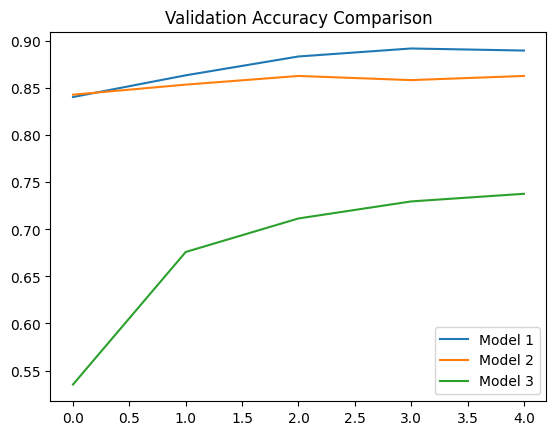

In [10]:

# Plot comparison
for i, history in enumerate(histories):
    plt.plot(history.history['val_accuracy'], label=f'Model {i+1}')

plt.title("Validation Accuracy Comparison")
plt.legend()
plt.show()
# Final model (best one)
best_model = model

In [11]:
# Predictions on multiple samples
print("\nSample Predictions:")
for i in range(5):
    pred = best_model.predict(x_test[i:i+1])
    print(f"Predicted: {class_names[np.argmax(pred)]} | Actual: {class_names[y_test[i]]}")


Sample Predictions:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 479ms/step
Predicted: Ankle boot | Actual: Ankle boot
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Predicted: Pullover | Actual: Pullover
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Predicted: Trouser | Actual: Trouser
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Predicted: Trouser | Actual: Trouser
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Predicted: Pullover | Actual: Shirt


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


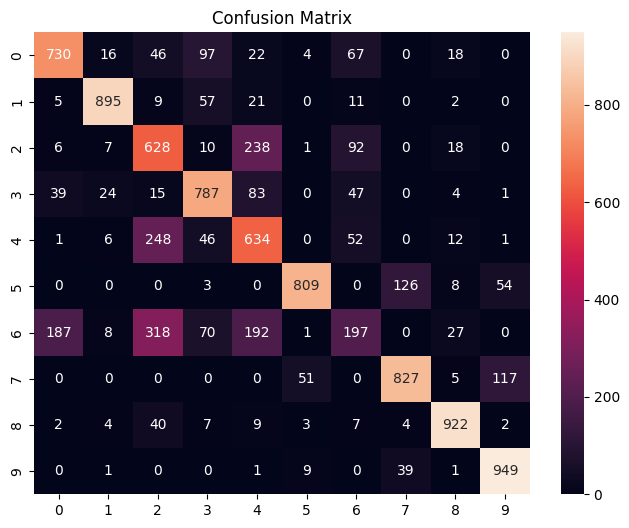

In [12]:
# 📊 Confusion Matrix
y_pred = best_model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

In [13]:


#  Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_classes))


Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.73      0.74      1000
           1       0.93      0.90      0.91      1000
           2       0.48      0.63      0.55      1000
           3       0.73      0.79      0.76      1000
           4       0.53      0.63      0.58      1000
           5       0.92      0.81      0.86      1000
           6       0.42      0.20      0.27      1000
           7       0.83      0.83      0.83      1000
           8       0.91      0.92      0.91      1000
           9       0.84      0.95      0.89      1000

    accuracy                           0.74     10000
   macro avg       0.73      0.74      0.73     10000
weighted avg       0.73      0.74      0.73     10000

